В этом задании вам предстоит продолжить работу с датасетом lenta-ru-news для той же задачи - классификации текстов по топикам. Можно переиспользовать подготовленные данные из ДЗ 1 или загрузить их заново.

1. Разделите датасет на обучающую, валидационную и тестовую выборки со стратификацией в пропорции 60/20/20. В качестве целевой переменной используйте атрибут topic
2. Обучите word2vec-эмбеддинги с помощью библиотеки gensim - **2 балла**
  * создайте модель для обучения на ваших данных, опишите, какими значениями вы инициализировали гиперпараметры модели, и почему
  * визуально оцените внутреннее (intrinsic) качество получившихся эмбеддингов, используя методы gensim - doesnt_match, most_similar
3. Загрузите предобученные эмбеддинги из navec и rusvectores (на ваш вкус) - **1 балл**
4. Обучите модель sklearn.linear_model.LogisticRegression с тремя вариантами векторизации текстов и сравните их качество между собой на валидационной выборке: **2 балла**
  * ваши эмбеддинги w2v
  * предобученные эмбеддинги navec
  * предобученные эмбеддинги rusvectores
5. Попробуйте улучшить качество модели, взяв для ее обучения лучший набор эмбеддингов и используя его с взвешиванием через tf-idf. То есть, необходимо каждый текст представить в виде взвешенного усреднения эмбеддингов его слов, где весами являются соответствующие коэффициенты tf-idf - **2 балла**
6. Финально сравните качество всех моделей на тестовой выборке - **1 балл**


Общее

Принимаемые решения обоснованы (почему выбрана определенная архитектура/гиперпараметр/оптимизатор/преобразование и т.п.) - **1 балл**

Обеспечена воспроизводимость решения: зафиксированы random_state, ноутбук воспроизводится от начала до конца без ошибок - **1 балл**

> Добавить блок с цитатой



In [ ]:
%%capture
!pip install gensim

In [ ]:
%%capture
!pip install navec

In [ ]:
import numpy as np
import pandas as pd
import random

from sklearn.model_selection import train_test_split, GridSearchCV
import gensim
from gensim.models import Word2Vec
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score
from tqdm import tqdm
from navec import Navec


import matplotlib.pyplot as plt
import seaborn as sns

### Фиксирование random_seed для воспроизводимости

In [ ]:
RANDOM_STATE = 42

def set_random_seed():
    np.random.seed(RANDOM_STATE)
    random.seed(RANDOM_STATE)

set_random_seed()

In [ ]:
df=pd.read_csv('preprocessed_df.csv')

### Разделение выборки

In [ ]:
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df['text'], df['topic'], test_size=0.4, random_state=42)
val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42)


### Токенизация данных

In [ ]:
train_tokens = [text.split() for text in train_texts]

### Обучение word2vec

In [ ]:
w2v_model = gensim.models.Word2Vec(
    sentences=train_tokens,  # список токенизированных предложений
    vector_size=100,  # размерность векторного представления слова
    window=5,  # размер окна для анализа контекста слова
    min_count=5,  # минимальное количество появлений слова в корпусе
    workers=4,  # количество потоков для обучения
    sg=1,  # используем Skip-gram (sg=1), а не CBOW (sg=0)
    epochs=10  # количество эпох обучения
)
w2v_model.save("word2vec.model")

# Обоснование параметров:
# - vector_size=100: баланс между качеством эмбеддингов и вычислительными затратами.
# - window=5: небольшое контекстное окно для захвата локальных связей между словами.
# - min_count=5: убираем редкие слова, чтобы модель не запоминала шум.
# - sg=1: Skip-gram работает лучше на малых данных, чем CBOW.
# - epochs=10: достаточное количество эпох для качественного обучения без переобучения.

# Оценка эмбеддингов
print("Похожие слова к 'россия':", w2v_model.wv.most_similar("россия"))
print("Лишнее слово в 'москва петербург киев омск':", w2v_model.wv.doesnt_match("москва петербург киев омск".split()))

Похожие слова к 'россия': [('белоруссия', 0.6817241311073303), ('российский', 0.6692781448364258), ('кобяк', 0.6655530333518982), ('станишева', 0.6208803057670593), ('белорусие', 0.6142544150352478), ('кулеб', 0.6141603589057922), ('минспорт', 0.6070716381072998), ('страна', 0.6042424440383911), ('микольский', 0.6038106083869934), ('белоруссиисоюз', 0.5981391668319702)]
Лишнее слово в 'москва петербург киев омск': киев


In [ ]:
from google.colab import files
files.download('word2vec.model')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

#### Визуализация для примера (топ-10 слов)

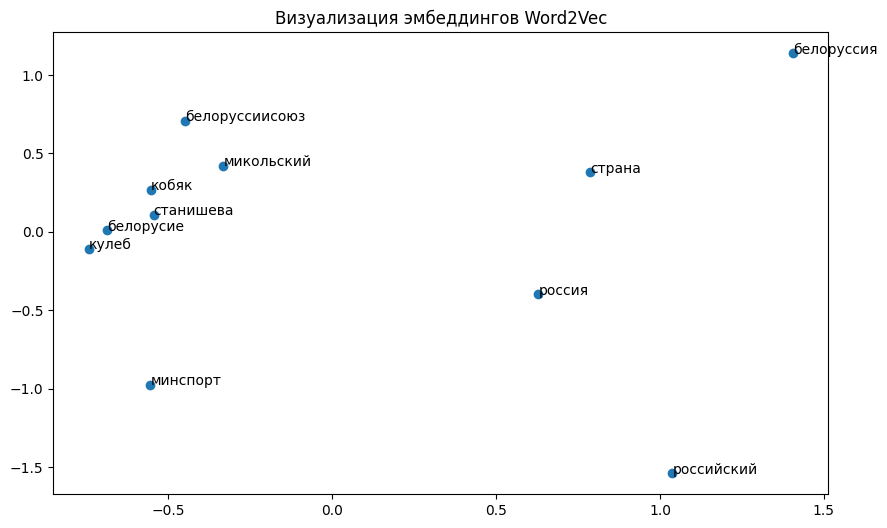

In [ ]:
word = "россия"
top_words = [word] + [w[0] for w in w2v_model.wv.most_similar(word, topn=10)]

X = np.array([w2v_model.wv[w] for w in top_words])

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1])
for i, word in enumerate(top_words):
    plt.annotate(word, (X_pca[i, 0], X_pca[i, 1]))
plt.title("Визуализация эмбеддингов Word2Vec")
plt.show()

### Загрузка предобученных эмбеддингов navec

In [ ]:
!wget https://storage.yandexcloud.net/natasha-navec/packs/navec_news_v1_1B_250K_300d_100q.tar

--2025-03-17 13:26:28--  https://storage.yandexcloud.net/natasha-navec/packs/navec_news_v1_1B_250K_300d_100q.tar
Resolving storage.yandexcloud.net (storage.yandexcloud.net)... 213.180.193.243, 2a02:6b8::1d9
Connecting to storage.yandexcloud.net (storage.yandexcloud.net)|213.180.193.243|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 26634240 (25M) [application/x-tar]
Saving to: ‘navec_news_v1_1B_250K_300d_100q.tar’

navec_news_v1_1B_25 100%[===================>]  25.40M  11.9MB/s    in 2.1s    

2025-03-17 13:26:31 (11.9 MB/s) - ‘navec_news_v1_1B_250K_300d_100q.tar’ saved [26634240/26634240]



In [ ]:
path = 'navec_news_v1_1B_250K_300d_100q.tar'
navec = Navec.load(path)
navec['россия'][:15]

array([-0.18471098, -0.11100645,  0.08644193,  0.2270673 ,  0.02942725,
        0.3612441 ,  0.6843062 ,  0.30184293,  0.5982135 ,  0.32763943,
       -0.0899637 , -0.00426673, -0.13530588, -0.15316929, -0.98540395],
      dtype=float32)

### RusVectors

In [ ]:
import urllib.request

In [ ]:
urllib.request.urlretrieve(
    "https://rusvectores.org/static/models/rusvectores4/ruwikiruscorpora/ruwikiruscorpora_upos_skipgram_300_2_2018.vec.gz",
    "ruwikiruscorpora_upos_skipgram_300_2_2018.vec.gz"
)

('ruwikiruscorpora_upos_skipgram_300_2_2018.vec.gz',
 <http.client.HTTPMessage at 0x7bda29354750>)

In [ ]:
model_path = 'ruwikiruscorpora_upos_skipgram_300_2_2018.vec.gz'
model_ru = gensim.models.KeyedVectors.load_word2vec_format(model_path)

### Перевод текстов в векторный вид

In [ ]:
def text_to_vector_navec(text, model):
    vectors = [model[word] for word in text.split() if word in model]
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.pq.dim)

def text_to_vector(text, model):
    vectors = []
    for word in text.split():
        if word in model:
            vectors.append(model[word])
    if vectors:
        return np.mean(vectors, axis=0)
    return np.zeros(model.vector_size)


# Векторизация текстов
train_vectors_w2v = np.array([text_to_vector(text, w2v_model.wv) for text in train_texts])
val_vectors_w2v = np.array([text_to_vector(text, w2v_model.wv) for text in val_texts])
train_vectors_navec = np.array([text_to_vector_navec(text, navec) for text in train_texts])
val_vectors_navec = np.array([text_to_vector_navec(text, navec) for text in val_texts])
train_vectors_rusvectores = np.array([text_to_vector(text, model_ru) for text in train_texts])
val_vectors_rusvectores = np.array([text_to_vector(text, model_ru) for text in val_texts])


### Обучение логистической регрессии

In [ ]:
clf_w2v = LogisticRegression(max_iter=1000, random_state=42)
clf_w2v.fit(train_vectors_w2v, train_labels)
y_pred_w2v = clf_w2v.predict(val_vectors_w2v)

clf_navec = LogisticRegression(max_iter=1000, random_state=42)
clf_navec.fit(train_vectors_navec, train_labels)
y_pred_navec = clf_navec.predict(val_vectors_navec)

clf_rusvectores = LogisticRegression(max_iter=1000, random_state=42)
clf_rusvectores.fit(train_vectors_rusvectores, train_labels)
y_pred_rusvectores = clf_rusvectores.predict(val_vectors_rusvectores)


print("Word2Vec Accuracy:", accuracy_score(val_labels, y_pred_w2v))
print("Navec Accuracy:", accuracy_score(val_labels, y_pred_navec))
print("RusVectores Accuracy:", accuracy_score(val_labels, y_pred_rusvectores))

Word2Vec Accuracy: 0.7736434108527132
Navec Accuracy: 0.7733933483370843
RusVectores Accuracy: 0.21845461365341334


Лучше всего получилось векторизовать тексты при помощи Word2Vec алгоритма. RusVectores показал себя хуже всех остальных, возможно, надо поэкспериментировать с другими моделями или другой предобработкой.

### Улучшение модели с TF-IDF

In [ ]:
vectorizer = TfidfVectorizer()
tfidf_weights = vectorizer.fit_transform(train_texts)
idf_dict = dict(zip(vectorizer.get_feature_names_out(), vectorizer.idf_))

def text_to_weighted_vector(text, model, idf_dict):
    vectors = []
    for word in text.split():
        if word in model and word in idf_dict:
            vectors.append(model[word] * idf_dict[word])
    return np.mean(vectors, axis=0) if vectors else np.zeros(model.vector_size)

train_vectors_tfidf = np.array([text_to_weighted_vector(text, w2v_model.wv, idf_dict) for text in train_texts])
val_vectors_tfidf = np.array([text_to_weighted_vector(text, w2v_model.wv, idf_dict) for text in val_texts])

clf_tfidf = LogisticRegression(max_iter=1000, random_state=42)
clf_tfidf.fit(train_vectors_tfidf, train_labels)
y_pred_tfidf = clf_tfidf.predict(val_vectors_tfidf)

print("TF-IDF Weighted Word2Vec Accuracy:", accuracy_score(val_labels, y_pred_tfidf))


TF-IDF Weighted Word2Vec Accuracy: 0.7755438859714928


TF-IDF действительно улучшил метрику Accuracy на 0.002 пункта.

### Финальная оценка на тестовой выборке

In [ ]:
test_vectors_tfidf = np.array([text_to_weighted_vector(text, w2v_model.wv, idf_dict) for text in test_texts])
y_pred_test = clf_tfidf.predict(test_vectors_tfidf)
print("Final Test Accuracy:", accuracy_score(test_labels, y_pred_test))


Final Test Accuracy: 0.7771554310862172


Финальная оценка на тестовой выборе получилась выше, чем Accuracy до этого.